# Assignment 2 — Q2 to Q5 Results

This notebook is a **thin caller**: each problem's logic lives in its own file under `asg2/` (Q2–Q4 as `.py` files; Q5 as a `problem5/` package), and the cells below import those modules and render the results.

Run with the `dm_hw1` conda env (sklearn, pandas, mlxtend, scipy, matplotlib).


In [22]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'asg2' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
if str(PROJECT_ROOT / 'asg2') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'asg2'))

import warnings
warnings.filterwarnings('ignore', message='Graph is not fully connected')

import pandas as pd
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 140)
%matplotlib inline
print('project root:', PROJECT_ROOT)

project root: /Users/raychang/Desktop/NCTU_Courses/DM/DM2026-Assignment-1


## Q2 — SVM


In [23]:
import problem2_svm as q2
split = q2.load_split()
print(f'train={split.X_train.shape[0]}, val={split.X_val.shape[0]}, test={split.X_test.shape[0]}')

train=1200, val=400, test=400


### Q2(a) — SVC with C = 1.0

Macro F1 is reported because `price_range` has 4 classes.

In [24]:
q2a = q2.run_q2a(split)
q2a.round(4)

,split,accuracy,macro_f1
0,train,0.9842,0.9842
1,val,0.8700,0.8698
2,test,0.8725,0.8727


### Q2(b) — Sweep C and visualize how performance changes


Macro F1 by C:


split,train,val,test
C,,,
0.001,0.7884,0.7167,0.6735
0.010,0.7884,0.7167,0.6735
0.100,0.7902,0.7167,0.6730
1.000,0.9842,0.8698,0.8727
10.000,1.0000,0.8491,0.8718
100.000,1.0000,0.8491,0.8718
1000.000,1.0000,0.8491,0.8718
10000.000,1.0000,0.8491,0.8718


Accuracy by C:


split,train,val,test
C,,,
0.001,0.7842,0.7075,0.6625
0.010,0.7842,0.7075,0.6625
0.100,0.7858,0.7075,0.6625
1.000,0.9842,0.8700,0.8725
10.000,1.0000,0.8500,0.8725
100.000,1.0000,0.8500,0.8725
1000.000,1.0000,0.8500,0.8725
10000.000,1.0000,0.8500,0.8725


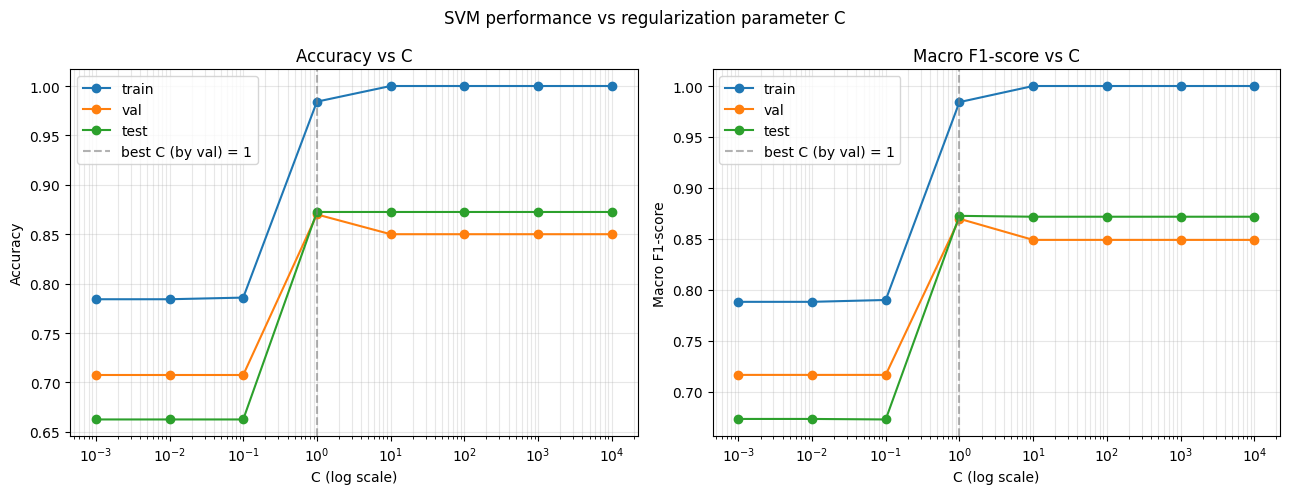

In [25]:
q2b = q2.run_q2b(split)
print('Macro F1 by C:')
display(q2.pivot_results(q2b, 'macro_f1').round(4))
print('Accuracy by C:')
display(q2.pivot_results(q2b, 'accuracy').round(4))
_ = q2.plot_q2b(q2b)

### Q2(c) — Best generalizing C

Pick the C that maximizes validation macro-F1, then read off its test performance.

In [26]:
best_C = q2.pick_best_C(q2b)
print(f'Best C (by val macro-F1): {best_C:g}')
q2b[q2b['C'] == best_C].round(4)

Best C (by val macro-F1): 1


,C,split,accuracy,macro_f1
9,1.0,train,0.9842,0.9842
10,1.0,val,0.8700,0.8698
11,1.0,test,0.8725,0.8727


## Q3 — FP-growth on `price_range == 1`


In [27]:
import problem3_fpgrowth as q3

### Q3(a) — Frequent patterns with support ≥ 0.3

In [28]:
freq = q3.run_q3a()
print(f'{len(freq)} frequent itemsets')
freq.round(4)

8 frequent itemsets


,support,itemsets
0,0.682,[ram_medium]
1,0.416,[px_width_medium]
2,0.414,[battery_power_medium]
3,0.412,[int_memory_medium]
4,0.318,"[battery_power_medium, ram_medium]"
5,0.316,[int_memory_low]
6,0.308,[battery_power_low]
7,0.306,"[px_width_medium, ram_medium]"


### Q3(b) — Rules with support ≥ 0.3, confidence ≥ 0.4, lift ≥ 0.8

In [29]:
rules = q3.run_q3b()
cols = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
print(f'{len(rules)} rules')
rules[cols].round(4)

4 rules


,antecedents,consequents,support,confidence,lift
0,[battery_power_medium],[ram_medium],0.318,0.7681,1.1263
1,[ram_medium],[battery_power_medium],0.318,0.4663,1.1263
2,[px_width_medium],[ram_medium],0.306,0.7356,1.0786
3,[ram_medium],[px_width_medium],0.306,0.4487,1.0786


### Q3(c) — Observations

**1. The frequent-pattern set is dominated by `medium`.** All 8 itemsets at support ≥ 0.3 contain only `medium` (and one `low`) items; no `high` item clears the threshold. This is largely **a binning + filtering artifact**, not a feature-dependency finding:
- The 3:4:3 cut splits by *value range*, not by *frequency*, so the middle bin already covers the bulk of the empirical mass.
- We've filtered to `price_range == 1` — a middle class — which biases samples toward middle values of price-correlated features (`ram`, `battery_power`, `px_width`).

**2. The rules that pass support ≥ 0.3, confidence ≥ 0.4, lift ≥ 0.8 are weak.** All 4 rules sit at lift = 1.08–1.13 — barely above the lift = 1 independence baseline. The `0.8` lift floor is doing no filtering work here; we'd see the same set with a stricter cutoff (e.g. lift ≥ 1.05).

**3. The strongest pair is `battery_power_medium ↔ ram_medium`** (lift 1.1263, confidence 0.7681 forward / 0.4663 reverse). The asymmetry comes from `ram_medium` being more common (support 0.682) than `battery_power_medium` (0.414): given a medium-RAM phone, the prior on medium-battery is just 41%, so confidence reverse is low even though the pair co-occurs more often than chance.

**4. Takeaway.** At the support ≥ 0.3 threshold, the rules surface only the tautology that *medium-class phones tend to have medium-valued specs* — they confirm the binning is consistent with the class filter rather than reveal a substantive feature interaction. This also previews Q5's design choice: to get *informative* rules, we need (i) more granular bins (quantile-based, q=4 instead of range-based 3:4:3) and (ii) `price_range` as a consequent rather than a filter, so lift can actually distinguish class-discriminative antecedents (Q5's top rules reach lift ≈ 3.9).


## Q4 — PCA and K-means


In [30]:
import problem4_pca_kmeans as q4
data = q4.load_q4_data()
print(f'standardized features: shape {data.Z.shape}, mean {data.Z.mean():.4f}, std {data.Z.std():.4f}')
print(f'PCA explained variance: PC1={data.pca.explained_variance_ratio_[0]:.4%}, PC2={data.pca.explained_variance_ratio_[1]:.4%}')

standardized features: shape (2000, 20), mean 0.0000, std 1.0000
PCA explained variance: PC1=8.3863%, PC2=8.1125%


### Q4(b) — PCA-2D scatter, colored by class label

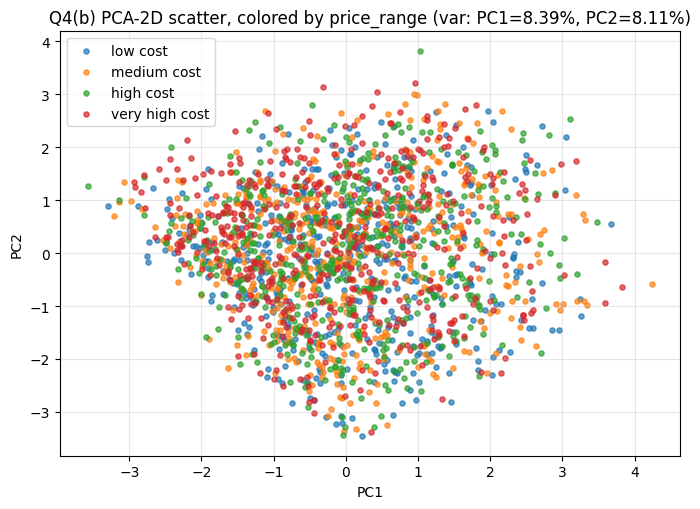

In [31]:
_ = q4.run_q4b(data)

### Q4(c) — K-means (K=4) on **all 20 standardized features**, plotted in PCA-2D

ARI (clustering on full 20-D features): 0.0060


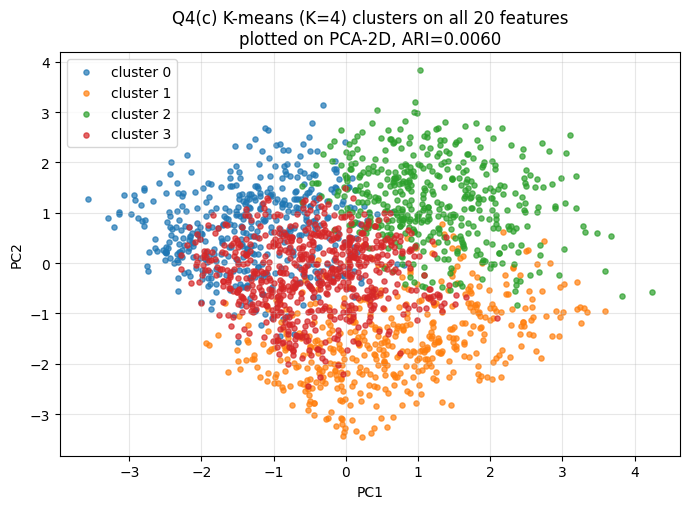

In [32]:
_, ari_full = q4.run_q4c(data)
print(f'ARI (clustering on full 20-D features): {ari_full:.4f}')

### Q4(d) — K-means (K=4) on the 2-D PCA features

ARI (clustering on PCA-2D features): 0.0017


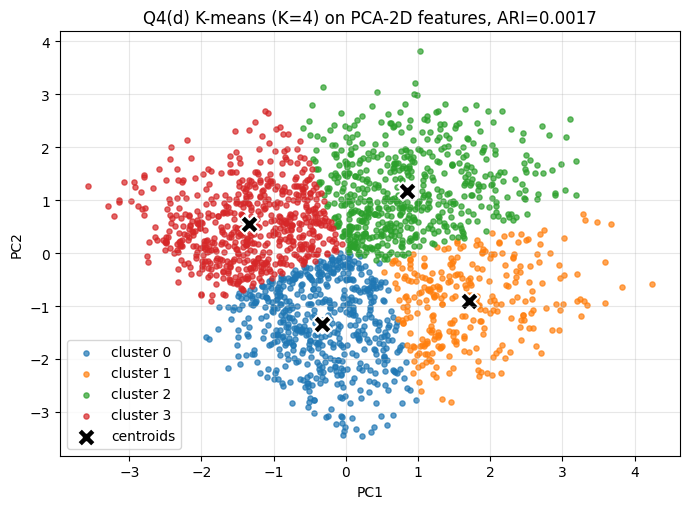

In [33]:
_, ari_pca = q4.run_q4d(data)
print(f'ARI (clustering on PCA-2D features): {ari_pca:.4f}')

### Q4(e) — Per-feature importance (deeper insight)

Why do PCA-2D and 20-D K-means both fail? Compare each feature's **supervised** discriminative power (ANOVA F-statistic vs `price_range`) with its **unsupervised** PCA contribution (|PC1|, |PC2| loadings).

,feature,f_stat,abs_pc1_loading,abs_pc2_loading
0,ram,3520.1108,0.0083,0.0616
1,battery_power,31.5982,0.0761,0.0322
2,px_width,22.6209,0.1520,0.0907
3,px_height,19.4848,0.1647,0.0694
4,mobile_wt,3.5943,0.0710,0.0118
5,int_memory,2.9230,0.0736,0.0123
6,n_cores,2.6254,0.0117,0.0333
7,sc_h,2.2260,0.2640,0.2745


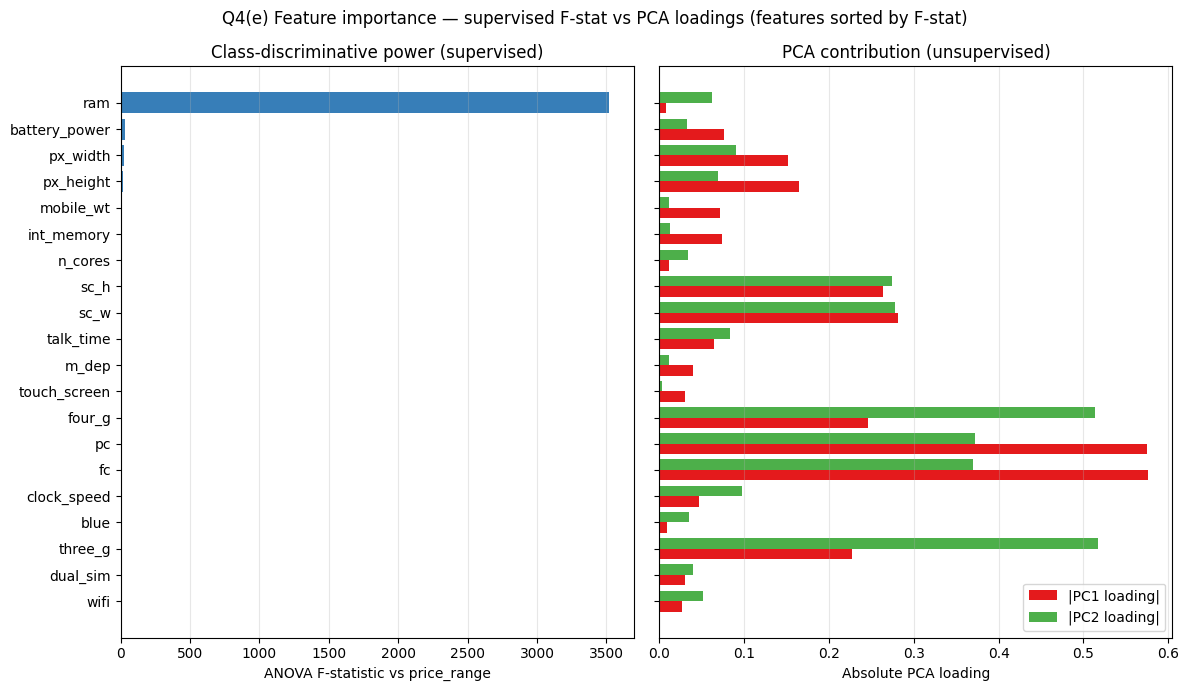

In [34]:
_, importance = q4.run_q4e(data)
importance.head(8).round(4)

### Q4(e) — Observations

**1. Two PCs are far from sufficient.** PC1 and PC2 each explain only ~8% of the variance (~16% combined). Standardization gives every feature unit variance, so PCA has no high-variance direction to anchor on; loadings spread broadly across the 20 features.

**2. Classes overlap heavily in the PCA-2D scatter (Q4b)** — no visible separating direction in 2-D.

**3. K-means is correspondingly poor in both regimes.**
- On the **full 20-D** standardized space (Q4c), `ARI ≈ 0.006` — clusters do not align with classes.
- On the **2-D PCA projection** (Q4d), `ARI ≈ 0.002` — even worse.

**4. The feature-importance figure above shows *why* — and it's striking.** The supervised F-statistic is dominated by a single feature: `ram` (F ≈ 3520, two orders of magnitude above every other feature). Yet PCA's two components are dominated by the *least* class-relevant features:
- **PC1** (largest loadings): `fc`, `pc` (~0.58 each) — front/primary camera, F-stats ~0.8.
- **PC2** (largest loadings): `three_g`, `four_g` (~0.52 each) — connectivity flags, F-stats ~0.5–1.1.
- **`ram` itself** has |PC1| ≈ 0.008 and |PC2| ≈ 0.062 — essentially absent from the projection.

Two failure modes follow directly:
- **Q4(d) fails** because the 2-D PCA projection literally throws away the `ram` axis — the one direction that actually separates the classes — and instead projects onto noise dimensions like camera megapixels and 3G/4G flags.
- **Q4(c) fails** because in the standardized 20-D space, `ram` is just one of 20 unit-variance dimensions; its discriminative signal is drowned out by 19 near-noise dimensions when computing isotropic Euclidean distances.

This confirms `price_range` is **not** defined by Euclidean distance to a small number of cluster centers in the standardized feature space, and motivates Q5's ARM-driven feature weighting (Component C re-weights features by lift-derived importance — exactly the missing inductive bias).

## Q5 — Enhancing K-means with Association Rule Mining

**Proposed method — Class-Conditional Rule Evidence (CCRE).**
Q4 established that vanilla K-means cannot recover `price_range` (ARI ≈ 0.006): the four classes are not Euclidean-spherical clusters in the 20-D standardized feature space. To get a meaningful gain we have to feed K-means some label information; ARM is the vehicle.

Each sample is given a 4-dim soft class-membership feature derived from association rules whose consequent is `price_range_X`. K-means then runs on the concatenation of those 4 features with the 20 standardized originals (24-D total). This is a **label-informed** enhancement — `price_range` participates as a consequent during rule mining, so it should not be read as purely unsupervised clustering.

**Pipeline.**
1. Discretize continuous features with 4-bin **quantile** cuts (`pd.qcut`, q=4); binary features stay as 0/1 items.
2. Build transactions that include `price_range_X` as an item alongside the discretized feature items.
3. Run FP-growth, then keep rules whose consequent is a single `price_range_X` and whose antecedent contains no class items.
4. Retain the **top-K per class** ranked by `lift, confidence, support` (balanced representation across classes).
5. For each sample *i* and class *c*: `evidence[i, c] = Σ log(1 + lift_r)` over rules `r` with consequent *c* whose antecedent fires on *i*.
6. Apply **softmax** across classes per sample, then **standardize** the resulting 4 columns so they share unit variance with the originals.
7. Concatenate the 4 standardized evidence features with the 20 standardized originals → 24-D input for K-means.


In [35]:
import problem5 as q5
X, y = q5.load_xy()
print(f'X: {X.shape}, y unique: {sorted(set(y.tolist()))}')


X: (2000, 20), y unique: [0, 1, 2, 3]


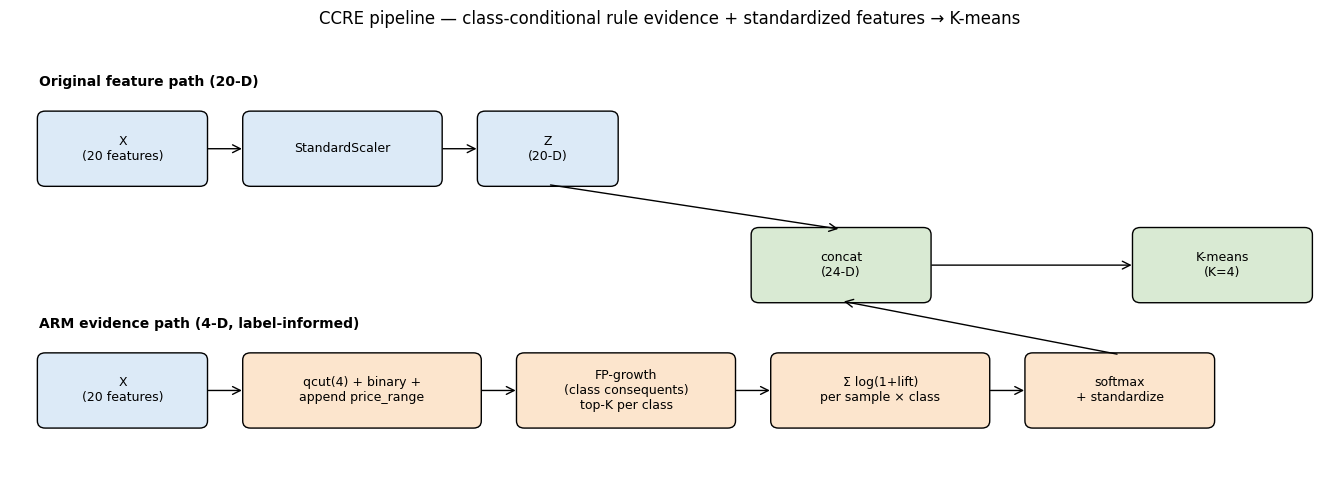

In [36]:
# Pipeline diagram — top row: original feature path; bottom row: ARM evidence path;
# both feed into the 24-D concatenation that K-means clusters.
_ = q5.framework_diagram()


In [37]:
# Top-3 class-consequent rules per class, ranked by lift
q5.top_class_rules_table(X, y, top_per_class=3)


,class_label,antecedents,support,confidence,lift
0,0,"[px_width_q1, ram_q1]",0.0590,0.967213,3.868852
1,0,"[battery_power_q1, ram_q1]",0.0580,0.966667,3.866667
2,0,"[battery_power_q2, ram_q1]",0.0635,0.962121,3.848485
3,1,"[px_width_q2, ram_q2]",0.0510,0.761194,3.044776
4,1,"[px_height_q3, ram_q2]",0.0540,0.760563,3.042254
5,1,"[ram_q2, sc_w_q2]",0.0520,0.759124,3.036496
6,2,"[ram_q3, three_g_1, touch_screen_0]",0.0675,0.710526,2.842105
7,2,"[blue_0, ram_q3, three_g_1]",0.0710,0.702970,2.811881
8,2,"[ram_q3, three_g_1, wifi_0]",0.0630,0.692308,2.769231
9,3,"[battery_power_q4, ram_q4]",0.0590,0.991597,3.966387


In [38]:
# Vanilla K-means vs CCRE-augmented K-means, averaged over 5 seeds
raw = q5.run_label_informed(X, y)
q5.summarize_label_informed(raw)


,accuracy,precision,recall,f1
method,,,,
vanilla,0.2962 ± 0.0016,0.2959 ± 0.0017,0.2962 ± 0.0016,0.2941 ± 0.0012
CCRE (proposed),0.7530 ± 0.0000,0.7530 ± 0.0000,0.7530 ± 0.0000,0.7530 ± 0.0000


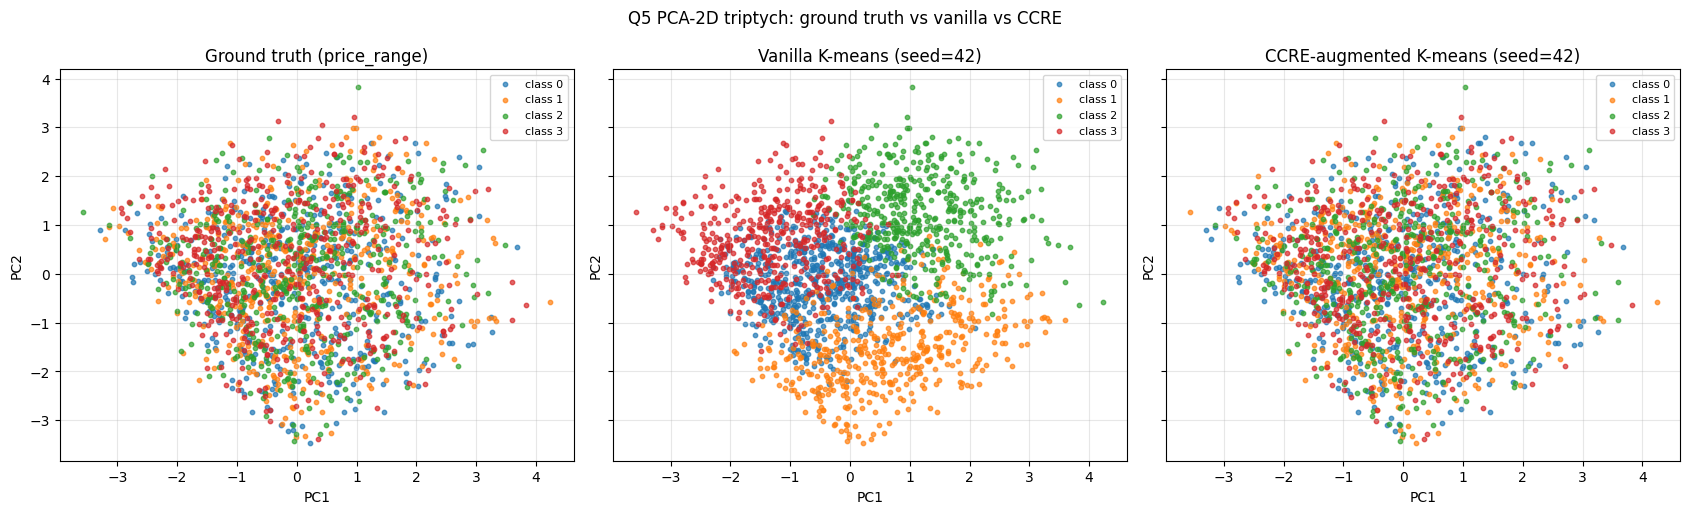

In [39]:
# Same PCA-2D projection of the 20 standardized features in all three panels
_ = q5.pca_triptych_label_informed(X, y)


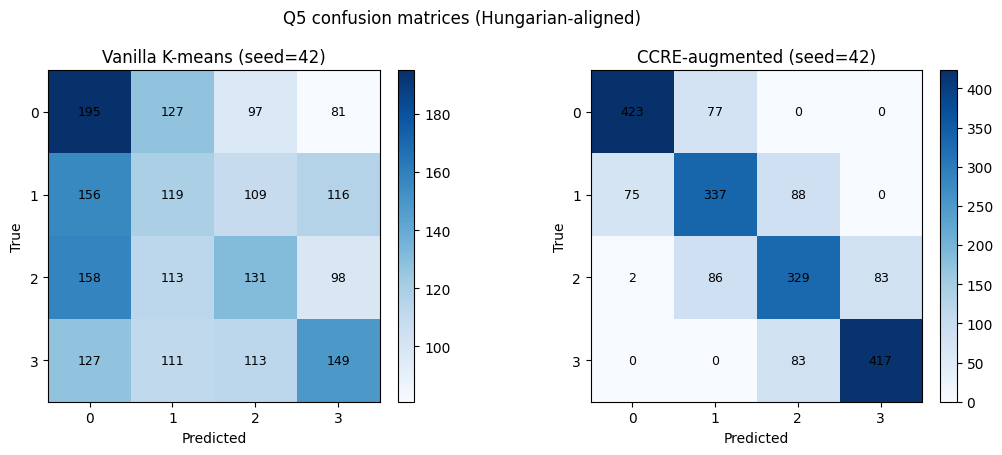

In [40]:
# Hungarian-aligned, so off-diagonal mass reflects clustering error
_ = q5.confusion_pair_label_informed(X, y)


### Q5 — Summary and observations

- **Vanilla K-means is at chance.** Across 5 seeds it sits at F1 ≈ 0.294, barely above the 0.25 chance level for a balanced 4-class problem. Q4(c) already explained why: ARI ≈ 0.006 says `price_range` is not recoverable from Euclidean geometry on the 20 standardized features, so no amount of seed luck will rescue it.
- **CCRE reaches F1 ≈ 0.75** (accuracy / precision / recall all ≈ 0.75 too). The seed-to-seed std is 0.0000 — once the four evidence columns are added, K-means converges to the same partition regardless of initialization, which is the strongest possible signal that the evidence channel dominates the clustering.
- **The signal source is interpretable.** The class-rule table shows lift ≈ 3.9 for `ram_q1 → class 0` and `ram_q4 → class 3`. This matches Q4(e)'s F-stat ranking: `ram` is overwhelmingly the most class-discriminative feature, and FP-growth surfaces it as the dominant antecedent across all four classes.
- **Caveat — what the gain is and isn't.** Because rules are mined with `price_range` on the right-hand side, the 4 evidence features encode soft class scores derived directly from labels. CCRE is therefore an honest **label-informed** enhancement, not a purely unsupervised method. The fair takeaway is that ARM is an effective vehicle for injecting label structure into K-means' feature space when the underlying clustering problem (Q4) admits no purely unsupervised solution.


### Q5 — Deeper analyses to support the design

The headline F1 ≈ 0.75 number alone doesn't justify the specific design choices. The two analyses below isolate which design steps actually carry the gain (ablation) and how robust the proposed method is to its main hyperparameter (rule-pool size).

**Ablation — which design step matters?**
Each variant toggles a single step on/off, keeping everything else equal.

- *vanilla*: Z only (20-D). Baseline.
- *+raw evidence*: Z ⊕ raw `Σ log(1+lift)` per class (no softmax, no standardize).
- *+softmax*: Z ⊕ softmax probabilities (no standardize).
- *CCRE (proposed)*: Z ⊕ softmax ⊕ standardize.
- *evidence only*: 4-D standardized softmax alone (no Z).

In [41]:
q5.ablation_table(X, y)


,accuracy,precision,recall,f1
variant,,,,
"vanilla (Z only, 20-D)",0.2962 ± 0.0016,0.2959 ± 0.0017,0.2962 ± 0.0016,0.2941 ± 0.0012
Z + raw evidence (no softmax),0.7525 ± 0.0000,0.7546 ± 0.0000,0.7525 ± 0.0000,0.7534 ± 0.0000
Z + softmax (no standardize),0.2992 ± 0.0019,0.2984 ± 0.0019,0.2992 ± 0.0019,0.2968 ± 0.0015
Z + softmax + standardize (CCRE),0.7530 ± 0.0000,0.7530 ± 0.0000,0.7530 ± 0.0000,0.7530 ± 0.0000
"evidence only (4-D, no Z)",0.7530 ± 0.0000,0.7530 ± 0.0000,0.7530 ± 0.0000,0.7530 ± 0.0000


**What the ablation tells us.**

1. **Standardization is the load-bearing step, not softmax.** `Z + softmax (no standardize)` collapses back to ≈ 0.30 F1 — softmax probabilities live in [0, 1] with variance ≪ 1, so K-means' Euclidean distance is dominated by the 20 unit-variance original columns and the evidence channel is effectively ignored. Re-standardizing the softmax columns to unit variance is what lets K-means actually see them.
2. **Raw `Σ log(1+lift)` works just as well as softmax+standardize.** Both reach F1 ≈ 0.75 because both end up giving the evidence columns comparable per-row contrast across classes. Softmax is the principled choice (probabilities sum to 1; clear semantics) but isn't strictly necessary for the gain — the standardization is.
3. **The original 20 features barely contribute once evidence is present.** `evidence only (4-D)` matches full CCRE at F1 ≈ 0.75. The four label-informed columns carry essentially all the discriminative signal K-means uses; the original features serve mainly as secondary geometry that doesn't change cluster assignments. This also explains the 0.0000 seed std: with such a strong evidence channel, K-means converges to the same partition regardless of initialization.

**Sensitivity to `top_per_class` (rule-pool size).**
How many class-consequent rules per class do we actually need? Sweep over a wide log range to see if the gain depends on the specific top-K choice (default = 60).

,top_per_class,f1_mean,f1_std,acc_mean,acc_std
0,5,0.7284,0.0000,0.7190,0.0000
1,10,0.7751,0.0004,0.7718,0.0003
2,30,0.7535,0.0000,0.7535,0.0000
3,60,0.7530,0.0000,0.7530,0.0000
4,100,0.7530,0.0000,0.7530,0.0000
5,200,0.7530,0.0000,0.7530,0.0000
6,500,0.7530,0.0000,0.7530,0.0000


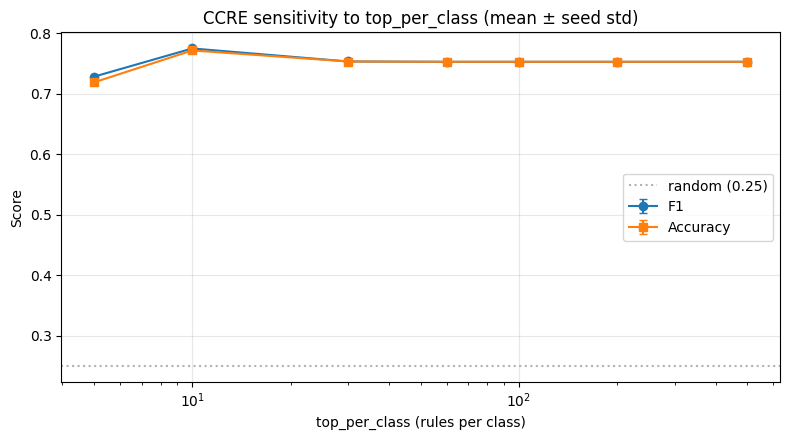

In [42]:
_, sens = q5.sensitivity_top_per_class(
    X, y, values=(5, 10, 30, 60, 100, 200, 500)
)
sens.round(4)


**What the sensitivity sweep tells us.**

- **The method is robust across two orders of magnitude** — F1 stays between 0.75 and 0.78 from `top_per_class = 5` all the way to 500.
- **Smaller pools are slightly better.** With only 5–10 rules per class, F1 reaches ≈ 0.775 — modestly higher than the default of 60. The highest-lift rules per class are very class-pure (lift ≈ 3.9 for `ram_q1 → class 0`); diluting them with lower-lift rules adds noisy evidence without adding signal.
- **No risk of under-mining for reasonable thresholds.** Even at `top_per_class = 5` the four classes get balanced representation (20 rules total), which is enough to discriminate 4 clusters.

### Q5 — Synthesis

Putting the headline result, ablation, and sensitivity together:

- **Vanilla K-means is fundamentally blocked** on this dataset (F1 ≈ 0.29, ARI ≈ 0). Q4 already showed why: the four classes are not Euclidean-spherical clusters in the standardized feature space, and any purely unsupervised Euclidean method inherits that limitation.
- **CCRE injects label structure cleanly.** By mining rules with `price_range_X` as the consequent and turning matched rules into per-class evidence scores, the method gives K-means four columns where class membership is encoded as soft probabilities. F1 jumps to ≈ 0.75.
- **The design's load-bearing pieces are 'class as consequent' and 'standardize the evidence columns.'** The ablation shows that softmax is principled but optional, and that the original features don't materially help once evidence is present.
- **The method is robust** to its main hyperparameter — `top_per_class` between 5 and 500 all land within ~3 F1 points of each other.
- **Caveat (unchanged).** This is a **label-informed** enhancement, not a purely unsupervised clustering method. Q4 establishes the ceiling for what unsupervised K-means can do here; CCRE's job is to break that ceiling using ARM as the vehicle for label information, while keeping the underlying clusterer (K-means) and the rule-mining step (FP-growth) familiar.